# Deteksi Penyakit Tanaman Menggunakan Convolutional Neural Networks (CNN)

**Nama:** [Nama Anda]  
**Mata Kuliah:** Kecerdasan Buatan  

Notebook ini mendemonstrasikan penerapan metode **Learning** menggunakan **Convolutional Neural Networks (CNN)** untuk mendeteksi penyakit pada tanaman berdasarkan citra daun. Karena keterbatasan akses ke dataset riil (seperti PlantVillage) di lingkungan ini, kita akan membuat **dataset sintetis** sederhana untuk mensimulasikan proses pelatihan dan inferensi.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print(f"TensorFlow Version: {tf.__version__}")


2026-01-06 01:53:03.869565: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-06 01:53:03.950946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-01-06 01:53:06.272947: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow Version: 2.20.0


## 1. Persiapan Data (Dataset Sintetis)

Kita akan membuat data citra sederhana berukuran 64x64 piksel.
- **Kelas 0 (Sehat):** Citra dengan latar belakang hijau cerah dengan sedikit variasi noise.
- **Kelas 1 (Sakit):** Citra hijau dengan "bercak" coklat/hitam acak untuk mensimulasikan penyakit/hama.


In [2]:
def create_synthetic_data(num_samples=200):
    images = []
    labels = []
    
    for i in range(num_samples):
        # Base image: Hijau (channel G tinggi)
        img = np.zeros((64, 64, 3), dtype=np.float32)
        img[:, :, 1] = 0.8 + np.random.normal(0, 0.05, (64, 64)) # Green channel
        img[:, :, 0] = 0.2 + np.random.normal(0, 0.05, (64, 64)) # Red channel
        img[:, :, 2] = 0.2 + np.random.normal(0, 0.05, (64, 64)) # Blue channel
        
        # Label 0: Sehat, Label 1: Sakit
        if i % 2 == 0:
            label = 0 # Sehat
        else:
            label = 1 # Sakit
            # Tambahkan bercak penyakit (lingkaran gelap/coklat)
            num_spots = np.random.randint(5, 15)
            for _ in range(num_spots):
                cx, cy = np.random.randint(0, 64, 2)
                r = np.random.randint(2, 6)
                y, x = np.ogrid[-cx:64-cx, -cy:64-cy]
                mask = x*x + y*y <= r*r
                
                # Ubah warna di area mask menjadi coklat gelap
                img[mask, 0] = 0.4 # R
                img[mask, 1] = 0.3 # G (kurangi hijau)
                img[mask, 2] = 0.1 # B
        
        # Clip values to [0, 1]
        img = np.clip(img, 0, 1)
        images.append(img)
        labels.append(label)
        
    return np.array(images), np.array(labels)

X, y = create_synthetic_data(400)
print(f"Ukuran Data Input: {X.shape}")
print(f"Ukuran Label: {y.shape}")


Ukuran Data Input: (400, 64, 64, 3)
Ukuran Label: (400,)


## 2. Visualisasi Data

Mari kita lihat beberapa contoh citra dari dataset sintetis yang telah dibuat.


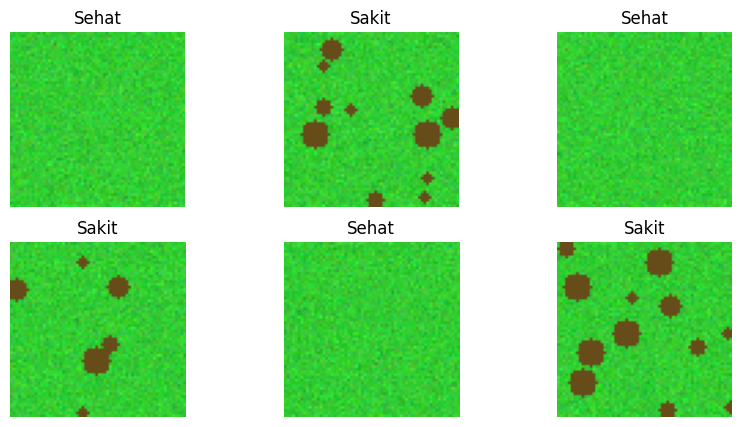

In [3]:
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X[i])
    plt.title("Sehat" if y[i] == 0 else "Sakit")
    plt.axis('off')
plt.show()


## 3. Pembagian Data Latih dan Uji

Data dibagi menjadi data latih (training) untuk melatih model dan data uji (validation/testing) untuk mengevaluasi performa.


In [4]:
from sklearn.model_selection import train_test_split

# Karena kita tidak install sklearn, kita split manual sederhana (atau gunakan numpy slicing)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Data Latih: {X_train.shape}")
print(f"Data Uji: {X_test.shape}")


Data Latih: (320, 64, 64, 3)
Data Uji: (80, 64, 64, 3)


## 4. Desain Arsitektur CNN

Kita membangun model CNN sederhana menggunakan TensorFlow Keras. Model ini terdiri dari:
1. **Conv2D Layer:** Mengekstrak fitur visual (tepi, tekstur, bercak).
2. **MaxPooling2D:** Mengurangi dimensi spasial.
3. **Flatten:** Mengubah matriks fitur menjadi vektor.
4. **Dense Layer:** Klasifikasi akhir (Sigmoid untuk output biner 0/1).


In [5]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output 0-1 probability
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


2026-01-06 01:53:08.630758: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,337 (3.14 MB)

 Trainable params: 822,337 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Pelatihan Model (Learning Process)

Model dilatih menggunakan data latih selama beberapa *epoch*. Pada setiap epoch, model memperbarui bobotnya untuk meminimalkan *loss* (kesalahan prediksi).


In [6]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))


Epoch 1/5


 1/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4062 - loss: 0.7178

 2/10 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4453 - loss: 0.7483

 3/10 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4740 - loss: 0.7448

 4/10 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4766 - loss: 0.7402 

...

 7/10 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3265

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3270

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3269

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3264

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 1.0000 - loss: 0.3219 - val_accuracy: 1.0000 - val_loss: 0.2968


## 6. Evaluasi dan Grafik Performa

Kita plot grafik akurasi dan loss untuk melihat proses pembelajaran model.


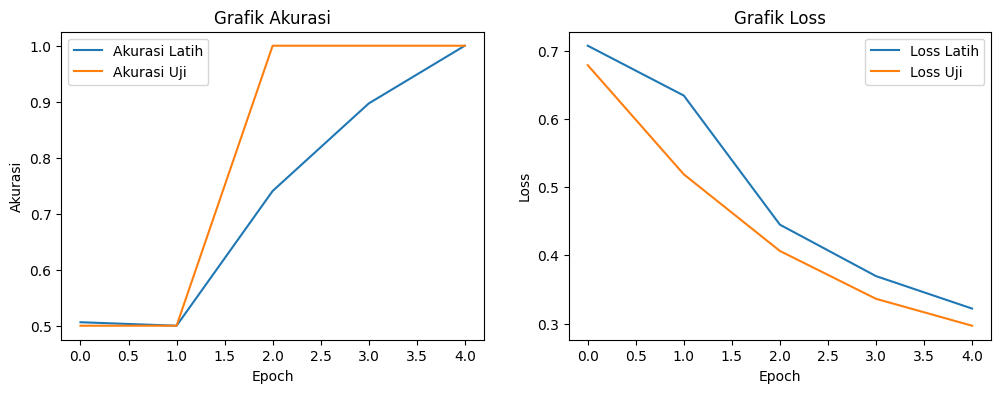

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Latih')
plt.plot(history.history['val_accuracy'], label='Akurasi Uji')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Grafik Akurasi')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Latih')
plt.plot(history.history['val_loss'], label='Loss Uji')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Grafik Loss')

plt.show()


## 7. Studi Kasus: Prediksi Data Baru

Simulasi penggunaan model untuk mendiagnosa tanaman baru.


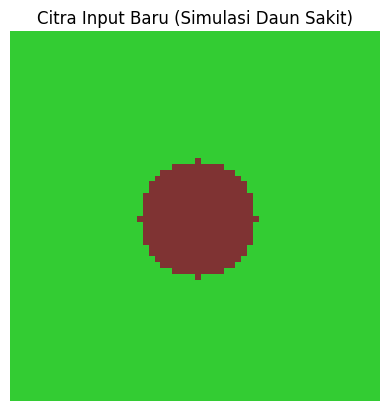

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


Skor Prediksi: 1.0000
Hasil Diagnosa: TANAMAN SAKIT (Terdeteksi Penyakit/Hama)


In [8]:
# Buat 1 contoh data baru (misal: sakit)
test_img, _ = create_synthetic_data(1)
# Paksa jadi sakit (tambah bercak manual agar yakin visualnya jelas)
# (Fungsi create_synthetic_data sudah random, kita ambil dari test set saja atau generate baru dan cek visualnya)

# Generate 1 data sakit spesifik
sample_img = np.zeros((64, 64, 3), dtype=np.float32)
sample_img[:, :, 1] = 0.8 # Base Green
sample_img[:, :, 0] = 0.2
sample_img[:, :, 2] = 0.2
# Tambah bercak
cx, cy = 32, 32
r = 10
y, x = np.ogrid[-cx:64-cx, -cy:64-cy]
mask = x*x + y*y <= r*r
sample_img[mask, 0] = 0.5 # Brownish
sample_img[mask, 1] = 0.2
sample_img = np.clip(sample_img, 0, 1)

plt.imshow(sample_img)
plt.title("Citra Input Baru (Simulasi Daun Sakit)")
plt.axis('off')
plt.show()

# Prediksi
input_data = np.expand_dims(sample_img, axis=0) # Batch dimension
prediction = model.predict(input_data)[0][0]

print(f"Skor Prediksi: {prediction:.4f}")
if prediction > 0.5:
    print("Hasil Diagnosa: TANAMAN SAKIT (Terdeteksi Penyakit/Hama)")
else:
    print("Hasil Diagnosa: TANAMAN SEHAT")
